### Exercitii

In [2]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
import os
from graphviz import Source
from sklearn.tree import export_graphviz
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

### Exercitiul 1

1. Use the following regression dataset:

X = np.random.rand(350 ,1)

y = (x + 1.2) ^ 3 - 10 + np.random.randn(350,1)/10,

in order to perform a regression task. Build a regression decision tree with
max_depth=3 and min_samples_leaf=5. Visualize the trained decision tree
and plot the regression predictions.

In [3]:
np.random.seed(42)
X = np.random.rand(350, 1)
y = (X + 1.2)**3 - 10 + np.random.randn(350, 1)/10

In [4]:
tree_reg = DecisionTreeRegressor(max_depth=3, min_samples_leaf=5, random_state=42)
tree_reg.fit(X, y)

DecisionTreeRegressor(max_depth=3, min_samples_leaf=5, random_state=42)

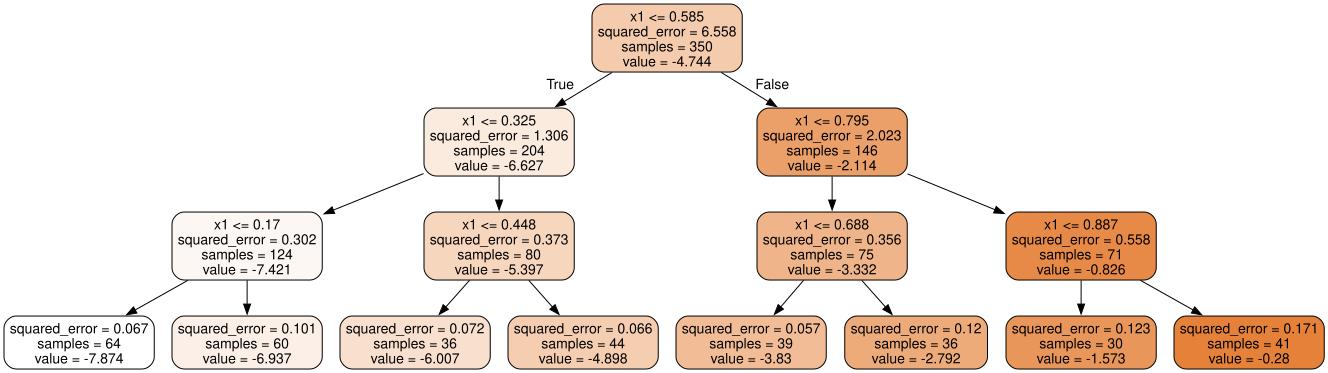

In [14]:
export_graphviz(
        tree_reg,
        out_file=os.path.join(".", "regression_tree.dot"),
        feature_names=["x1"],
        rounded=True,
        filled=True
    )

Source.from_file(os.path.join(".", "regression_tree.dot"))

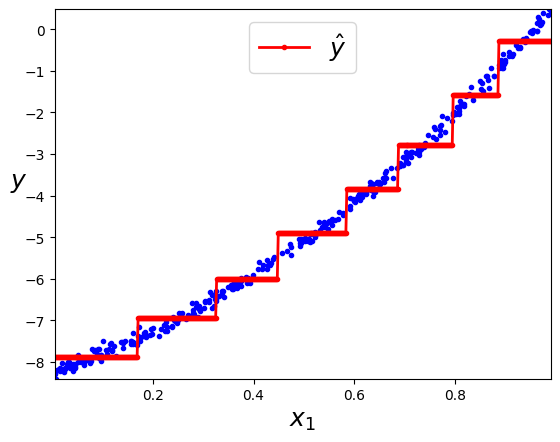

In [6]:
def plot_regression_predictions(tree_reg, X, y, axes=[np.amin(X), np.amax(X), np.amin(y), np.amax(y)]):
    x1 = np.linspace(axes[0], axes[1], 500).reshape(-1, 1)
    y_pred = tree_reg.predict(x1)
    plt.axis(axes)
    plt.xlabel("$x_1$", fontsize=18)
    plt.ylabel("$y$", fontsize=18, rotation=0)
    plt.plot(X, y, "b.")
    plt.plot(x1, y_pred, "r.-", linewidth=2, label=r"$\hat{y}$")

plot_regression_predictions(tree_reg, X, y)

plt.legend(loc="upper center", fontsize=18)

plt.show()

### Exercitiul 2

2. Use the digits dataset to perform a classification task using bagging. Set
the number of estimators to 200. The test split should be 15% of the initial
dataset. Print the accuracy of the model.

In [7]:
digits_dataset = datasets.load_digits()
X_train, X_test, y_train, y_test = train_test_split(digits_dataset['data'], digits_dataset['target'], random_state=0, test_size=0.15)

In [8]:
bag_clf = BaggingClassifier(
    DecisionTreeClassifier(), n_estimators=200,
    max_samples=100, bootstrap=True, random_state=42)
bag_clf.fit(X_train, y_train)
y_pred = bag_clf.predict(X_test)

In [9]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_pred))

0.9222222222222223


### Exercitiul 3

3. Use the following regression dataset:

X = np.random.rand(160 , 1) - 1

y = 2\*(X[;, 0])^2 + 0.2*np.random. randn(160),

in order to perform gradient boosting. The GradientBoostingRegressor
class has the hyperparameters: max_depth=2 and n_estimators=100. The
test split is 25% of the initial dataset. Use early stopping to find the optimal
number of trees and plot:
- the model's predictions with 100 estimators;
- the model's predictions with the optimal number of trees.

In [10]:
np.random.seed(42)

X = np.random.rand(160,1) - 1
y = 2*X[:, 0]**2 + 0.2 * np.random.randn(160)

In [11]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=42)

gbrt = GradientBoostingRegressor(max_depth=2, n_estimators=100, random_state=42)
gbrt.fit(X_train, y_train)

errors = [mean_squared_error(y_val, y_pred)
          for y_pred in gbrt.staged_predict(X_val)]
bst_n_estimators = np.argmin(errors) + 1

gbrt_best = GradientBoostingRegressor(max_depth=2, n_estimators=bst_n_estimators, random_state=42)
gbrt_best.fit(X_train, y_train)

GradientBoostingRegressor(max_depth=2, n_estimators=39, random_state=42)

In [12]:
min_error = np.min(errors)

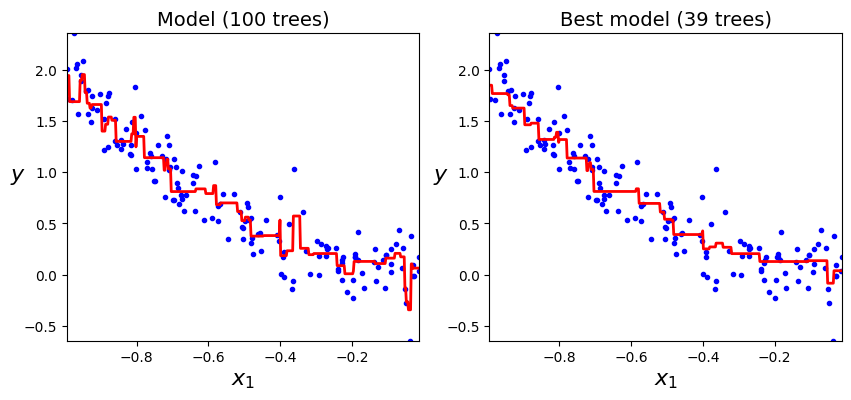

In [13]:
def plot_predictions(regressors, X, y, axes, label=None, style="r-", data_style="b.", data_label=None):
    x1 = np.linspace(axes[0], axes[1], 500)
    y_pred = sum(regressor.predict(x1.reshape(-1, 1)) for regressor in regressors)
    plt.plot(X[:, 0], y, data_style, label=data_label)
    plt.plot(x1, y_pred, style, linewidth=2, label=label)
    if label or data_label:
        plt.legend(loc="upper center", fontsize=16)
    plt.axis(axes)

plt.figure(figsize=(10, 4))

plt.subplot(121)
plot_predictions([gbrt], X, y, axes=[np.amin(X), np.amax(X), np.amin(y), np.amax(y)])
plt.title("Model (%d trees)" % 100, fontsize=14)
plt.ylabel("$y$", fontsize=16, rotation=0)
plt.xlabel("$x_1$", fontsize=16)

plt.subplot(122)

plot_predictions([gbrt_best], X, y, axes=[np.amin(X), np.amax(X), np.amin(y), np.amax(y)])
plt.title("Best model (%d trees)" % bst_n_estimators, fontsize=14)
plt.ylabel("$y$", fontsize=16, rotation=0)
plt.xlabel("$x_1$", fontsize=16)

plt.show()